[-7.0000184e-05 -6.2700000e-04  0.0000000e+00  0.0000000e+00
  0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00
  0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00
  0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00]


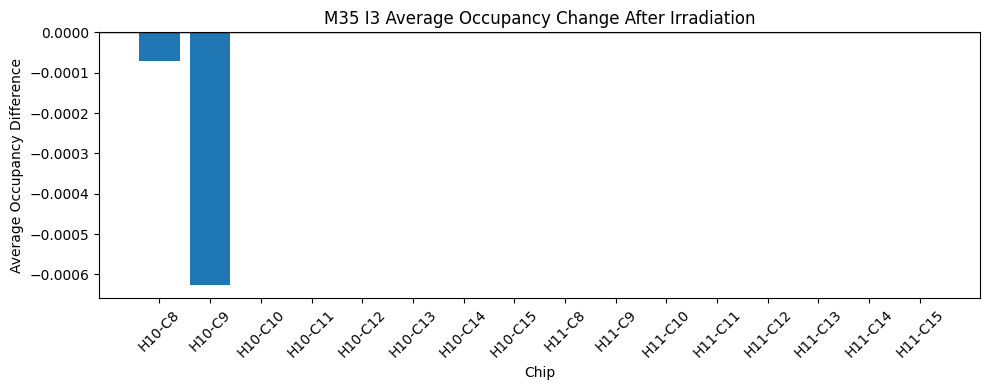

In [41]:
# MODULE 35, Iteration 3

# import necessary packages
import uproot
import numpy as np
import matplotlib.pyplot as plt


# define fxn to read 2d histogram and return values
def read_th2(root_file, path):

    with uproot.open(root_file) as f:
        hist = f[path]
        values, x_edges, y_edges = hist.to_numpy(flow=False)

    return values, x_edges, y_edges


#define fxn to find difference between noise pre rad cold and noise post rad
def diff_th2_paths(root_pre, path_pre,
                   root_post, path_post):

    values_pre, _, _ = read_th2(root_pre, path_pre)
    values_post, _, _ = read_th2(root_post, path_post)

    return values_post - values_pre


#define fxn to create file paths for files pre rad
def make_pre_histpath(hybrid, chip):

    return (
        f"Detector/Board_0/OpticalGroup_5/"
        f"Hybrid_{hybrid}/"
        f"MPA_{chip}/"
        f"D_B(0)_O(5)_H({hybrid})"
        f"_ChannelOccupancy_Injection_0.000_MIP_Chip({chip});1"
    )

#define fxn to  create file paths for files post rad in mod35
def make_post_histpath(hybrid, chip):

    return (
        f"Iteration_3_PSfullTest_2026-03-13_08-45-57/"
        f"Detector/Board_0/OpticalGroup_1/"
        f"Hybrid_{hybrid}/"
        f"MPA_{chip}/"
        f"D_B(0)_O(1)_H({hybrid})"
        f"_ChannelOccupancy_Injection_0.000_MIP_Chip({chip});1"
    )


#defines root files pre and post rad
root_pre = (
    "PS_16_FNL-10035_2025-12-02_04h37m52s_-33C_PSfullTest_v6-22.root"
)

root_post = (
    "/home/ekimrey/QPT_before_irradiation/"
    "post_irradiation_for_Emerson/"
    "TrackerHistos/TrackerHistos_42.root"
)

#map hybrids pre rad to their post rad counterpart
hybrid_map = {
    10: 2,   # pre H2 -> post H4
    11: 3    # pre H3 -> post H5
}


chip_diffs = []

for pre_hybrid in [10, 11]:

    post_hybrid = hybrid_map[pre_hybrid]

    for chip in range(8, 16):

        pre_path = make_pre_histpath(pre_hybrid, chip)
        post_path = make_post_histpath(post_hybrid, chip)

        values_pre, _, _ = read_th2(root_pre, pre_path)
        values_post, _, _ = read_th2(root_post, post_path)

        avg_pre = np.median(values_pre)
        avg_post = np.median(values_post)

        diff = avg_post - avg_pre

        chip_diffs.append(diff)


chip_diffs = np.array(chip_diffs)

print(chip_diffs)
labels = (
    [f"H10-C{chip}" for chip in range(8,16)] +
    [f"H11-C{chip}" for chip in range(8,16)]
)

fig, ax = plt.subplots(figsize=(10,4))

ax.bar(labels, chip_diffs)

ax.set_ylabel("Average Occupancy Difference")
ax.set_xlabel("Chip")
ax.set_title("M35 I3 Average Occupancy Change After Irradiation")

ax.axhline(0, color="black", linewidth=1)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



[-3.4300017e-04 -6.8499998e-05  0.0000000e+00  0.0000000e+00
  0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00
  0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00
  0.0000000e+00  0.0000000e+00  0.0000000e+00  1.7000000e-05]


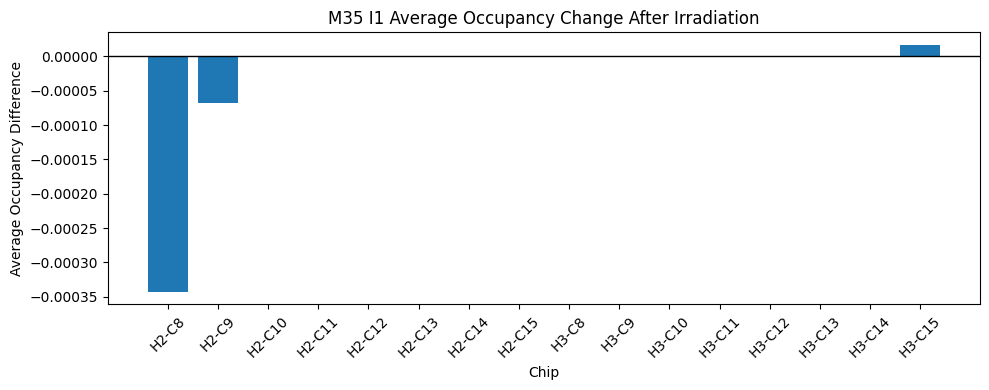

In [39]:
# MODULE 35, I1
# import necessary packages
import uproot
import numpy as np
import matplotlib.pyplot as plt


# define fxn to read 2d histogram and return values
def read_th2(root_file, path):

    with uproot.open(root_file) as f:
        hist = f[path]
        values, x_edges, y_edges = hist.to_numpy(flow=False)

    return values, x_edges, y_edges


#define fxn to find difference between noise pre rad cold and noise post rad
def diff_th2_paths(root_pre, path_pre,
                   root_post, path_post):

    values_pre, _, _ = read_th2(root_pre, path_pre)
    values_post, _, _ = read_th2(root_post, path_post)

    return values_post - values_pre


#define fxn to create file paths for files pre rad
def make_pre_histpath(hybrid, chip):

    return (
        f"Detector/Board_0/OpticalGroup_5/"
        f"Hybrid_{hybrid}/"
        f"MPA_{chip}/"
        f"D_B(0)_O(5)_H({hybrid})"
        f"_ChannelOccupancy_Injection_0.000_MIP_Chip({chip});1"
    )

#define fxn to  create file paths for files post rad in mod35
def make_post_histpath(hybrid, chip):

    return (
        f"Iteration_1_PSfullTest_2026-03-12_17-23-21/"
        f"Detector/Board_0/OpticalGroup_1/"
        f"Hybrid_{hybrid}/"
        f"MPA_{chip}/"
        f"D_B(0)_O(1)_H({hybrid})"
        f"_ChannelOccupancy_Injection_0.000_MIP_Chip({chip});1"
    )


#defines root files pre and post rad
root_pre = (
    "PS_16_FNL-10035_2025-12-02_04h37m52s_-33C_PSfullTest_v6-22.root"
)

root_post = (
    "/home/ekimrey/QPT_before_irradiation/"
    "post_irradiation_for_Emerson/"
    "TrackerHistos/TrackerHistos_42.root"
)

hybrid_map = {
    10: 2,   # pre H2 -> post H4
    11: 3    # pre H3 -> post H5
}


chip_diffs = []

for pre_hybrid in [10, 11]:

    post_hybrid = hybrid_map[pre_hybrid]

    for chip in range(8, 16):

        pre_path = make_pre_histpath(pre_hybrid, chip)
        post_path = make_post_histpath(post_hybrid, chip)

        values_pre, _, _ = read_th2(root_pre, pre_path)
        values_post, _, _ = read_th2(root_post, post_path)

        avg_pre = np.median(values_pre)
        avg_post = np.median(values_post)

        diff = avg_post - avg_pre

        chip_diffs.append(diff)

chip_diffs = np.array(chip_diffs)

print(chip_diffs)

fig, ax = plt.subplots(figsize=(10,4))

ax.bar(labels, chip_diffs)

ax.set_ylabel("Average Occupancy Difference")
ax.set_xlabel("Chip")
ax.set_title("M35 I1 Average Occupancy Change After Irradiation")

ax.axhline(0, color="black", linewidth=1)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

[-0.0031735 -0.0006015  0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        -0.0004785]


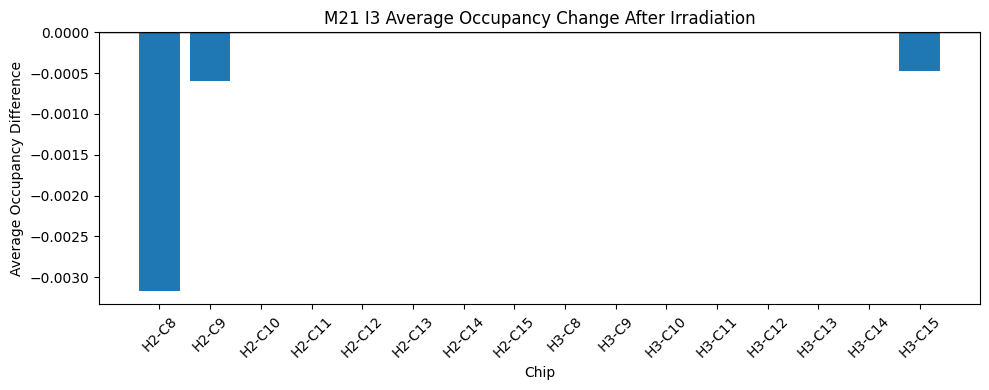

In [38]:
# MODULE 21
# import necessary packages
import uproot
import numpy as np
import matplotlib.pyplot as plt


# define fxn to read 2d histogram and return values
def read_th2(root_file, path):

    with uproot.open(root_file) as f:
        hist = f[path]
        values, x_edges, y_edges = hist.to_numpy(flow=False)

    return values, x_edges, y_edges


#define fxn to find difference between noise pre rad cold and noise post rad
def diff_th2_paths(root_pre, path_pre,
                   root_post, path_post):

    values_pre, _, _ = read_th2(root_pre, path_pre)
    values_post, _, _ = read_th2(root_post, path_post)

    return values_post - values_pre


#define fxn to create file paths for files pre rad
def make_pre_histpath(hybrid, chip):

    return (
        f"Detector/Board_0/OpticalGroup_1/"
        f"Hybrid_{hybrid}/"
        f"MPA_{chip}/"
        f"D_B(0)_O(1)_H({hybrid})"
        f"_ChannelOccupancy_Injection_0.000_MIP_Chip({chip});1"
    )

#define fxn to  create file paths for files post rad in mod35
def make_post_histpath(hybrid, chip):

    return (
        f"Iteration_3_PSfullTest_2026-03-13_08-45-57/"
        f"Detector/Board_0/OpticalGroup_2/"
        f"Hybrid_{hybrid}/"
        f"MPA_{chip}/"
        f"D_B(0)_O(2)_H({hybrid})"
        f"_ChannelOccupancy_Injection_0.000_MIP_Chip({chip});1"
    )


#defines root files pre and post rad
root_pre = (
    "PS_16_FNL-10021_2025-12-02_04h37m52s_-33C_PSfullTest_v6-22.root"
)

root_post = (
    "/home/ekimrey/QPT_before_irradiation/"
    "post_irradiation_for_Emerson/"
    "TrackerHistos/TrackerHistos_42.root"
)

hybrid_map = {
    2: 4,   # pre H2 -> post H4
    3: 5    # pre H3 -> post H5
}


chip_diffs = []

for pre_hybrid in [2, 3]:

    post_hybrid = hybrid_map[pre_hybrid]

    for chip in range(8, 16):

        pre_path = make_pre_histpath(pre_hybrid, chip)
        post_path = make_post_histpath(post_hybrid, chip)

        values_pre, _, _ = read_th2(root_pre, pre_path)
        values_post, _, _ = read_th2(root_post, post_path)

        avg_pre = np.median(values_pre)
        avg_post = np.median(values_post)

        diff = avg_post - avg_pre

        chip_diffs.append(diff)



chip_diffs = np.array(chip_diffs)

print(chip_diffs)

fig, ax = plt.subplots(figsize=(10,4))

ax.bar(labels, chip_diffs)

ax.set_ylabel("Average Occupancy Difference")
ax.set_xlabel("Chip")
ax.set_title("M21 I3 Average Occupancy Change After Irradiation")

ax.axhline(0, color="black", linewidth=1)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

[-0.0031845 -0.0006035  0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        -0.000576 ]


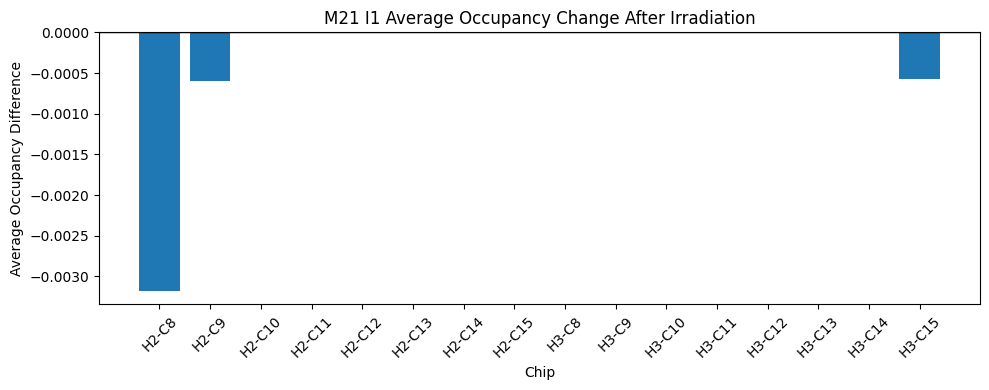

In [40]:
# MODULE 21, I1
# import necessary packages
import uproot
import numpy as np
import matplotlib.pyplot as plt


# define fxn to read 2d histogram and return values
def read_th2(root_file, path):

    with uproot.open(root_file) as f:
        hist = f[path]
        values, x_edges, y_edges = hist.to_numpy(flow=False)

    return values, x_edges, y_edges


#define fxn to find difference between noise pre rad cold and noise post rad
def diff_th2_paths(root_pre, path_pre,
                   root_post, path_post):

    values_pre, _, _ = read_th2(root_pre, path_pre)
    values_post, _, _ = read_th2(root_post, path_post)

    return values_post - values_pre


#define fxn to create file paths for files pre rad
def make_pre_histpath(hybrid, chip):

    return (
        f"Detector/Board_0/OpticalGroup_1/"
        f"Hybrid_{hybrid}/"
        f"MPA_{chip}/"
        f"D_B(0)_O(1)_H({hybrid})"
        f"_ChannelOccupancy_Injection_0.000_MIP_Chip({chip});1"
    )

#define fxn to  create file paths for files post rad in mod35
def make_post_histpath(hybrid, chip):

    return (
        f"Iteration_1_PSfullTest_2026-03-12_17-23-21/"
        f"Detector/Board_0/OpticalGroup_2/"
        f"Hybrid_{hybrid}/"
        f"MPA_{chip}/"
        f"D_B(0)_O(2)_H({hybrid})"
        f"_ChannelOccupancy_Injection_0.000_MIP_Chip({chip});1"
    )


#defines root files pre and post rad
root_pre = (
    "PS_16_FNL-10021_2025-12-02_04h37m52s_-33C_PSfullTest_v6-22.root"
)

root_post = (
    "/home/ekimrey/QPT_before_irradiation/"
    "post_irradiation_for_Emerson/"
    "TrackerHistos/TrackerHistos_42.root"
)

hybrid_map = {
    2: 4,   # pre H2 -> post H4
    3: 5    # pre H3 -> post H5
}


chip_diffs = []

for pre_hybrid in [2, 3]:

    post_hybrid = hybrid_map[pre_hybrid]

    for chip in range(8, 16):

        pre_path = make_pre_histpath(pre_hybrid, chip)
        post_path = make_post_histpath(post_hybrid, chip)

        values_pre, _, _ = read_th2(root_pre, pre_path)
        values_post, _, _ = read_th2(root_post, post_path)

        avg_pre = np.median(values_pre)
        avg_post = np.median(values_post)

        diff = avg_post - avg_pre

        chip_diffs.append(diff)


chip_diffs = np.array(chip_diffs)

print(chip_diffs)

fig, ax = plt.subplots(figsize=(10,4))

ax.bar(labels, chip_diffs)

ax.set_ylabel("Average Occupancy Difference")
ax.set_xlabel("Chip")
ax.set_title("M21 I1 Average Occupancy Change After Irradiation")

ax.axhline(0, color="black", linewidth=1)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()